In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
ds1 = xr.open_dataset("~/WPS/geo_em.d01.nc")

In [24]:
print(ds1)

<xarray.Dataset> Size: 9MB
Dimensions:     (Time: 1, south_north: 139, west_east: 119,
                 south_north_stag: 140, west_east_stag: 120, land_cat: 21,
                 soil_cat: 16, month: 12)
Dimensions without coordinates: Time, south_north, west_east, south_north_stag,
                                west_east_stag, land_cat, soil_cat, month
Data variables: (12/52)
    Times       (Time) |S19 19B ...
    XLAT_M      (Time, south_north, west_east) float32 66kB ...
    XLONG_M     (Time, south_north, west_east) float32 66kB ...
    XLAT_V      (Time, south_north_stag, west_east) float32 67kB ...
    XLONG_V     (Time, south_north_stag, west_east) float32 67kB ...
    XLAT_U      (Time, south_north, west_east_stag) float32 67kB ...
    ...          ...
    OA4         (Time, south_north, west_east) float32 66kB ...
    OL1         (Time, south_north, west_east) float32 66kB ...
    OL2         (Time, south_north, west_east) float32 66kB ...
    OL3         (Time, south_north

/home/erickwambugu/miniconda3/envs/wrf_venv/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


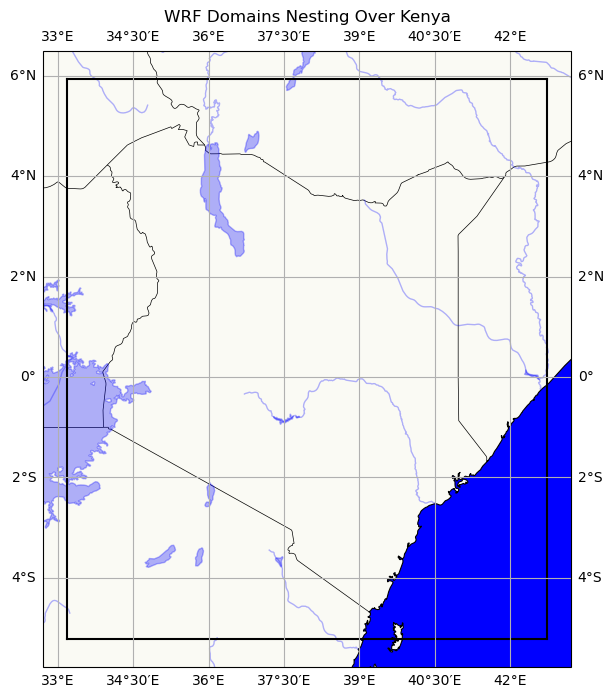

In [26]:
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=proj)

ax.plot(ds1.XLONG_M[0,:,0], ds1.XLAT_M[0,:,0], "k", transform=proj)
ax.plot(ds1.XLONG_M[0,:,-1], ds1.XLAT_M[0,:,-1], "k", transform=proj)
ax.plot(ds1.XLONG_M[0,0,:], ds1.XLAT_M[0,0,:], "k", transform=proj)
ax.plot(ds1.XLONG_M[0,-1,:], ds1.XLAT_M[0,-1,:], "k", transform=proj)

ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.OCEAN, facecolor="Blue")
ax.add_feature(cfeature.LAKES, facecolor="Blue", edgecolor="blue", alpha=0.3)
ax.add_feature(cfeature.RIVERS, facecolor="Blue", edgecolor="blue", alpha=0.3)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

ax.set_title("WRF Domains Nesting Over Kenya")
fig.savefig('kenya_d1.png', dpi=300, bbox_inches='tight')
plt.show()